In [6]:
import numpy as np
import mmcfilters
import matplotlib
import math

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16,16)

from IPython import display
from os import listdir
import cv2 as cv


from collections import defaultdict
def dfs(node, depth=0):
    nodes_by_depth[depth].append(node)
    for child in node.children:
        dfs(child, depth + 1)

from PrettyPrint import PrettyPrintTree
from colorama import Fore, Back
printTree = PrettyPrintTree(
    lambda node: node.children,
#    lambda node: ("id:" + str(node.id) + " " + str(node.isMaxtree)[0], "level:" + str(node.level) + " (" + str(node.residue) + ")", "|cnps|:" + str(len(node.cnps))  ), 
    lambda node: ("id:" + str(node.id) ), 
    color=Back.BLACK + Fore.WHITE
)

def mapIDs(tos):
    mapIDs = []
    for p in range(num_rows * num_cols):
        mapIDs.append( tos.getSC(p).id )
    return np.array(mapIDs).reshape(num_rows, num_cols)


In [43]:
imgInput = np.array([
        [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5],    
        [5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5],    
        [5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5],
        [5, 4, 1, 1, 1, 3, 7, 7, 7, 4, 5],
        [5, 4, 1, 1, 1, 7, 7, 7, 7, 4, 5],
        [5, 5, 5, 5, 2, 2, 4, 7, 7, 4, 5],
        [5, 4, 1, 1, 2, 4, 4, 7, 7, 4, 5],
        [5, 4, 1, 1, 4, 4, 4, 7, 7, 4, 5],
        [5, 4, 1, 1, 1, 7, 7, 7, 7, 4, 5],
        [5, 4, 1, 1, 1, 1, 7, 7, 7, 4, 5],
        [5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5],
        [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
])
(num_rows, num_cols) = imgInput.shape

tos = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols)
print("#Nodes:", tos.numNodes)
nodes_by_depth = defaultdict(list)
dfs(tos.root)
print(imgInput)
printTree(tos.root)
print("\n", mapIDs(tos))

#Nodes: 7
[[5 5 5 5 5 5 5 5 5 5 5]
 [5 4 4 4 4 4 4 4 4 4 5]
 [5 4 4 4 4 4 4 4 4 4 5]
 [5 4 1 1 1 3 7 7 7 4 5]
 [5 4 1 1 1 7 7 7 7 4 5]
 [5 5 5 5 2 4 4 7 7 4 5]
 [5 4 1 1 2 4 4 7 7 4 5]
 [5 4 1 1 4 4 4 7 7 4 5]
 [5 4 1 1 1 7 7 7 7 4 5]
 [5 4 1 1 1 1 7 7 7 4 5]
 [5 4 4 4 4 4 4 4 4 4 5]
 [5 5 5 5 5 5 5 5 5 5 5]]
         id:0 
          |
         id:1 
     ┌────┴─────┐
    id:2       id:6 
     |              
    id:3            
  ┌──┴───┐          
 id:4   id:5 

 [[0 0 0 0 0 0 0 0 0 0 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 1 5 5 5 2 6 6 6 1 0]
 [0 1 5 5 5 6 6 6 6 1 0]
 [0 0 0 0 3 1 1 6 6 1 0]
 [0 1 4 4 3 1 1 6 6 1 0]
 [0 1 4 4 1 1 1 6 6 1 0]
 [0 1 4 4 4 6 6 6 6 1 0]
 [0 1 4 4 4 4 6 6 6 1 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 0 0 0 0 0 0 0 0 0 0]]


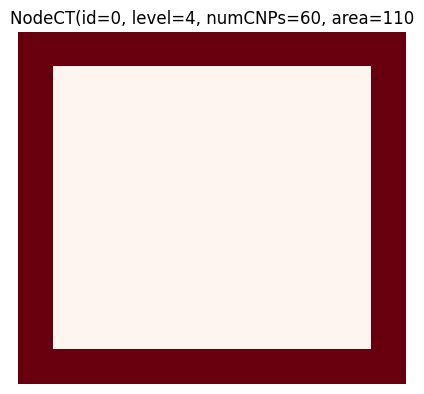

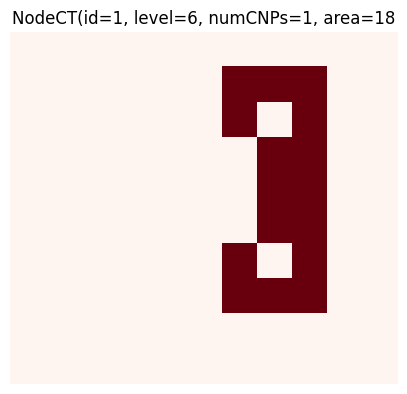

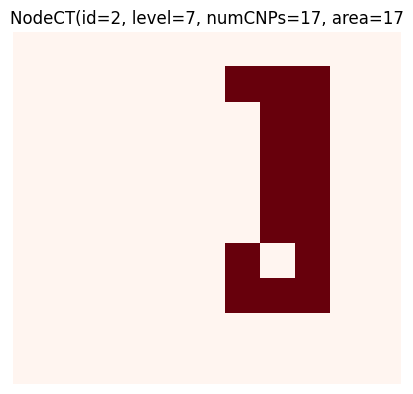

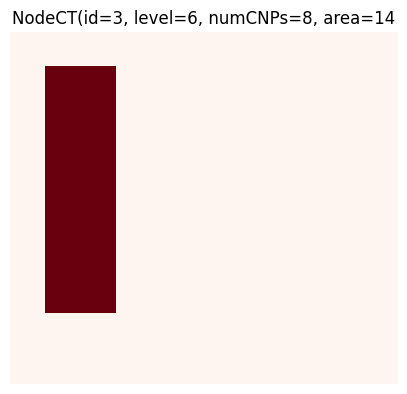

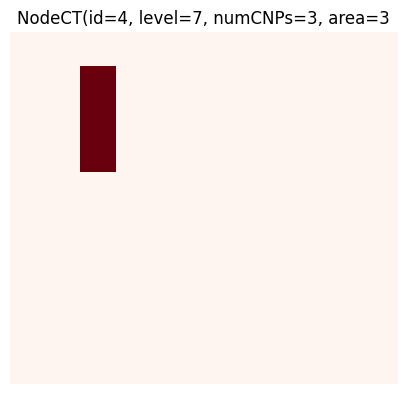

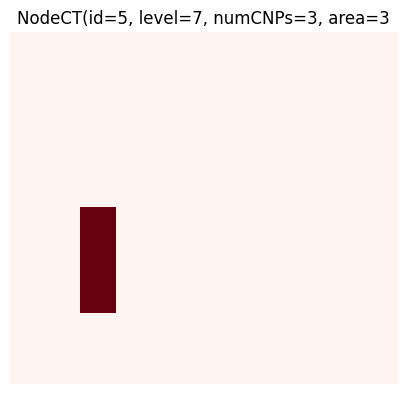

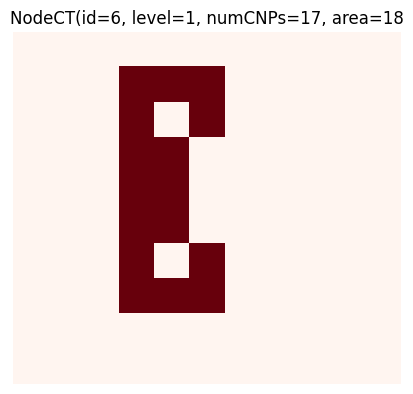

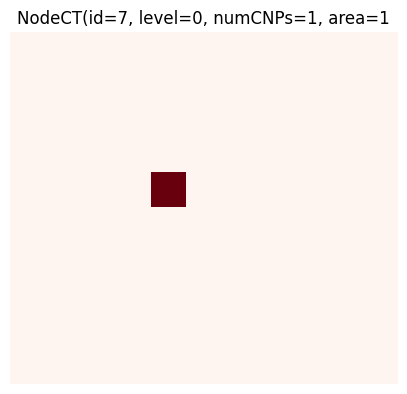

In [9]:
def plotCountors(pixels, node, num_rows, num_cols):
    contour_img = np.zeros((num_rows, num_cols), dtype=np.uint8)
    
    for p in pixels:
        row = p // num_cols
        col = p % num_cols
        contour_img[row, col] = 255  
    
    # Plotar com matplotlib
    plt.figure(figsize=(5, 5))
    plt.imshow(contour_img, cmap='Reds')
    plt.title(node)
    plt.axis('off')
    plt.show()

countors = mmcfilters.Attribute.extractCountors(tos)
nodes = tos.listNodes
for node in nodes:
    plotCountors(countors[node.id], node, num_rows, num_cols)

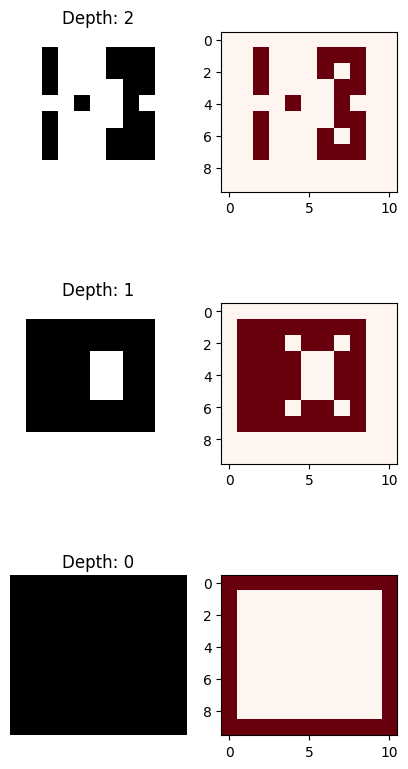

In [4]:
from itertools import chain


countors = mmcfilters.Attribute.extractCountors(tos)

def plotImageBin(nodes_by_depth, num_rows, num_cols):
    numImagens = len(nodes_by_depth)
    fig, axes = plt.subplots(numImagens,2, figsize=(5, 10))
    for i, depth in enumerate(range(numImagens-1, -1, -1)):
        imgBin = np.zeros((num_rows, num_cols), dtype=np.uint8)
        contour_img = np.zeros((num_rows, num_cols), dtype=np.uint8)
            
        for node in nodes_by_depth[depth]:
            for p in countors[node.id]:
                row = p // num_cols
                col = p % num_cols
                contour_img[row, col] = 1  

            for p in node.pixelsOfCC():
                row = p // num_cols
                col = p % num_cols
                imgBin[row, col] = 1  

        axes[i,0].imshow(imgBin, cmap='gray_r', vmax=1, vmin=0, interpolation='nearest')
        axes[i,1].imshow(contour_img, cmap='Reds')
        axes[i,0].set_title(f'Depth: {depth}')
        axes[i,0].axis('off')
       
    plt.show()

plotImageBin(nodes_by_depth, num_rows, num_cols)